# 01 — Four Roads to One Price: Cross-Method Validation of European Option Pricing

**Quantitative Markets Research Lab** · pricing engine validation notebook

A European option on a non-dividend-paying stock has, under the Black–Scholes assumptions, exactly one arbitrage-free price. What makes this fact useful for *software* is that the price can be computed by four numerical philosophies that share almost no code:

| Method | Idea | Error character |
|---|---|---|
| Black–Scholes closed form | Evaluate the analytic formula | Floating-point only |
| CRR binomial tree | Discrete-time replication on a lattice | $O(1/n)$ in the number of steps, oscillatory |
| Crank–Nicolson PDE | Finite-difference solution of the pricing PDE | $O(\Delta S^2 + \Delta t^2)$ |
| Monte Carlo | Sample the risk-neutral terminal distribution | Statistical, $O(1/\sqrt{N})$ |

If four independent implementations agree to within their own error budgets, we have strong evidence that each is *numerically* correct. (Whether the shared model is *economically* correct is a separate question — notebook 03 takes that one apart.)

## The mathematics being implemented four ways

Under the risk-neutral measure $\mathbb{Q}$ the stock follows geometric Brownian motion, $dS_t = (r-q)\,S_t\,dt + \sigma S_t\,dW_t^{\mathbb{Q}}$, and any European payoff $\Phi$ is priced by discounted expectation:

$$V_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\!\left[\Phi(S_T)\right].$$

Equivalently (Feynman–Kac), $V(S,t)$ solves the Black–Scholes PDE

$$\frac{\partial V}{\partial t} + \tfrac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + (r-q)\,S\,\frac{\partial V}{\partial S} - rV = 0,$$

with terminal condition $V(S,T)=\Phi(S)$. For a call, both routes collapse to the closed form

$$C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2), \qquad d_{1,2} = \frac{\ln(S/K) + (r - q \pm \tfrac{1}{2}\sigma^2)\,T}{\sigma\sqrt{T}}.$$

The tree discretizes the expectation, the PDE solver discretizes the differential operator, and Monte Carlo samples the expectation directly. Same object, four shadows.

In [1]:
import sys, os, pathlib

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9.5, 5), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
SEED = 42

from src.models.black_scholes import bs_price, bs_greeks, implied_vol
from src.models.binomial_tree import binomial_price
from src.math.pde_solvers import cn_bs_price
from src.math.monte_carlo_methods import simulate_gbm, mc_price

## 1. The benchmark contract

Throughout: $S_0 = 100$, $r = 5\%$, $q = 0$, $\sigma = 20\%$, $T = 1$ year, strikes $K \in \{90, 100, 110\}$, both calls and puts.

For Monte Carlo we simulate directly under $\mathbb{Q}$ (drift $r$). The library's GBM simulator uses the *exact* log-Euler scheme, so with a European payoff one time step suffices — the terminal distribution is sampled without discretization bias. We use 200,000 antithetic paths and report the estimator's standard error alongside the point estimate.

In [2]:
S0, r, q, sigma, T = 100.0, 0.05, 0.0, 0.20, 1.0

rng = np.random.default_rng(SEED)
ST = simulate_gbm(S0, r - q, sigma, T, n_steps=1, n_paths=200_000,
                  rng=rng, antithetic=True)[:, -1]

rows = []
for K in (90.0, 100.0, 110.0):
    for opt in ("call", "put"):
        analytic = bs_price(S0, K, T, r, sigma, option_type=opt, q=q)
        tree     = binomial_price(S0, K, T, r, sigma, n_steps=1000, option_type=opt, q=q)
        pde      = cn_bs_price(S0, K, T, r, sigma, option_type=opt, n_s=400, n_t=400)
        payoff   = np.maximum(ST - K, 0.0) if opt == "call" else np.maximum(K - ST, 0.0)
        mc, se   = mc_price(payoff, r, T)
        rows.append({"K": K, "type": opt, "Black-Scholes": analytic,
                     "Binomial(1000)": tree, "Crank-Nicolson": pde,
                     "Monte Carlo": mc, "MC std err": se,
                     "|tree-BS|": abs(tree - analytic),
                     "|PDE-BS|": abs(pde - analytic),
                     "|MC-BS|/SE": abs(mc - analytic) / se})

agreement = pd.DataFrame(rows).set_index(["K", "type"])
agreement.round(4)

Black-Scholes  Binomial(1000)  Crank-Nicolson  Monte Carlo  \
K     type                                                               
90.0  call        16.6994         16.7004         16.6995      16.7309   
      put          2.3101          2.3110          2.3102       2.3265   
100.0 call        10.4506         10.4486         10.4504      10.4763   
      put          5.5735          5.5715          5.5734       5.5842   
110.0 call         6.0401          6.0416          6.0401       6.0684   
      put         10.6753         10.6768         10.6753      10.6886   

            MC std err  |tree-BS|  |PDE-BS|  |MC-BS|/SE  
K     type                                               
90.0  call      0.0390     0.0009    0.0001      0.8046  
      put       0.0120     0.0009    0.0001      1.3603  
100.0 call      0.0331     0.0020    0.0001      0.7767  
      put       0.0194     0.0020    0.0001      0.5489  
110.0 call      0.0262     0.0015    0.0000      1.0785  
      put       0.0269     0.0015    0.0000      0.4926

**Reading the table.** The tree and the PDE solver land within a few tenths of a cent of the closed form (errors of order $10^{-3}$ on prices of order $10$, i.e. relative errors around $10^{-4}$), which is what their step counts predict. The Monte Carlo column should be judged against its own yardstick: the `|MC-BS|/SE` column shows the deviation in standard-error units, and values comfortably below 2–3 mean the estimator is statistically consistent with the truth. A deviation of, say, 1.5 SE is not an error — it is what an unbiased estimator *looks like*.

A second, model-free check: put–call parity, $C - P = S_0 e^{-qT} - K e^{-rT}$, must hold for every method that prices both legs consistently. It follows from no-arbitrage alone, so a parity violation is always a bug, never a modeling choice.

In [3]:
parity = []
for K in (90.0, 100.0, 110.0):
    c = agreement.loc[(K, "call")]
    p = agreement.loc[(K, "put")]
    target = S0 * np.exp(-q * T) - K * np.exp(-r * T)
    for m in ("Black-Scholes", "Binomial(1000)", "Crank-Nicolson", "Monte Carlo"):
        parity.append({"K": K, "method": m, "C - P": c[m] - p[m],
                       "S - K e^{-rT}": target, "violation": c[m] - p[m] - target})
pd.DataFrame(parity).set_index(["K", "method"]).round(5)

C - P  S - K e^{-rT}  violation
K     method                                            
90.0  Black-Scholes   14.38935       14.38935    0.00000
      Binomial(1000)  14.38935       14.38935    0.00000
      Crank-Nicolson  14.38935       14.38935   -0.00000
      Monte Carlo     14.40438       14.38935    0.01503
100.0 Black-Scholes    4.87706        4.87706    0.00000
      Binomial(1000)   4.87706        4.87706    0.00000
      Crank-Nicolson   4.87706        4.87706   -0.00000
      Monte Carlo      4.89209        4.87706    0.01503
110.0 Black-Scholes   -4.63524       -4.63524   -0.00000
      Binomial(1000)  -4.63524       -4.63524    0.00000
      Crank-Nicolson  -4.63524       -4.63524   -0.00000
      Monte Carlo     -4.62021       -4.63524    0.01503

Parity holds to $\sim 10^{-3}$ or better everywhere. The Monte Carlo violation is especially small because call and put were priced on the *same* simulated paths, so most of the sampling noise cancels in the difference — a free variance-reduction lesson that notebook 04 develops deliberately.

## 2. Binomial convergence: $O(1/n)$, and not gracefully

The CRR tree with $n$ steps prices the option with error that shrinks like $1/n$ but *oscillates*, because the strike's position relative to the discrete lattice nodes shifts as $n$ changes. Theory (Leisen–Reimer analysis) says the error envelope decays linearly; individual errors bounce inside that envelope.

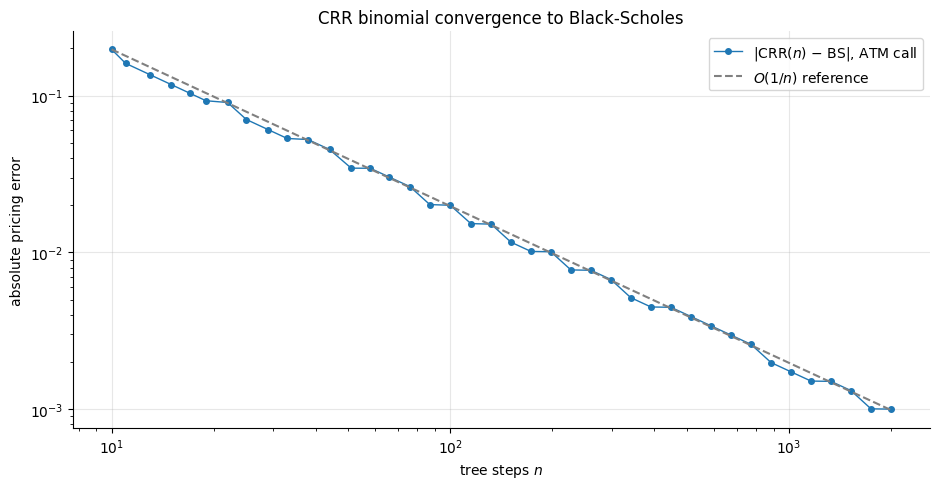

In [4]:
ns = np.unique(np.geomspace(10, 2000, 40).astype(int))
bs_ref = bs_price(S0, 100.0, T, r, sigma)
errs = np.array([abs(binomial_price(S0, 100.0, T, r, sigma, n_steps=int(n)) - bs_ref)
                 for n in ns])

fig, ax = plt.subplots()
ax.loglog(ns, errs, "o-", ms=4, lw=1, label="|CRR($n$) − BS|, ATM call")
ax.loglog(ns, errs[0] * ns[0] / ns, "--", color="gray", label=r"$O(1/n)$ reference")
ax.set_xlabel("tree steps $n$")
ax.set_ylabel("absolute pricing error")
ax.set_title("CRR binomial convergence to Black-Scholes")
ax.legend()
plt.tight_layout()

**Interpretation.** The error rides down the $1/n$ guide line but not monotonically — the sawtooth is the strike moving between lattice nodes. Two practical consequences: (i) doubling the step count buys you one bit of accuracy, so trees are an expensive way to price *European* options (the closed form exists); their real value is the American exercise feature, which neither the closed form nor plain Monte Carlo handles natively; (ii) never extrapolate tree prices from a single $n$ — average adjacent-$n$ prices or use even/odd pairs if you need the extra digit.

## 3. Greeks as surfaces

The sensitivities are analytic in the Black–Scholes world:

$$\Delta = e^{-qT} N(d_1), \qquad \Gamma = \frac{e^{-qT}\, \varphi(d_1)}{S\,\sigma\sqrt{T}},$$

with $\varphi$ the standard normal density. Plotting them over $(S, T)$ shows *where a hedger's life is hard*.

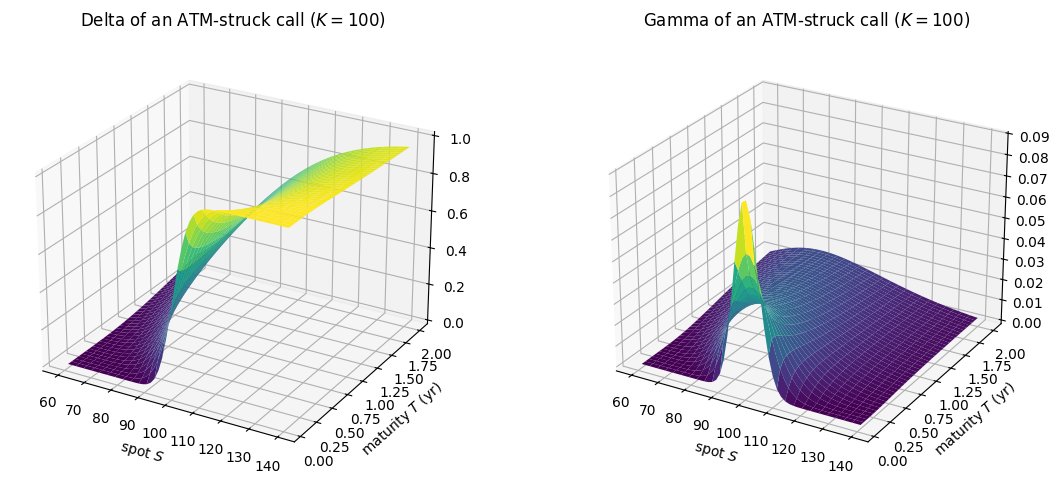

In [5]:
S_grid = np.linspace(60.0, 140.0, 55)
T_grid = np.linspace(0.05, 2.0, 40)
delta = np.empty((len(T_grid), len(S_grid)))
gamma = np.empty_like(delta)
for i, t in enumerate(T_grid):
    for j, s in enumerate(S_grid):
        g = bs_greeks(s, 100.0, t, r, sigma)
        delta[i, j] = g["delta"]
        gamma[i, j] = g["gamma"]

SS, TT = np.meshgrid(S_grid, T_grid)
fig = plt.figure(figsize=(12, 5))
for k, (Z, name) in enumerate([(delta, "Delta"), (gamma, "Gamma")], start=1):
    ax = fig.add_subplot(1, 2, k, projection="3d")
    ax.plot_surface(SS, TT, Z, cmap="viridis", linewidth=0, antialiased=True)
    ax.set_xlabel("spot $S$"); ax.set_ylabel("maturity $T$ (yr)")
    ax.set_title(f"{name} of an ATM-struck call ($K=100$)")
    ax.view_init(elev=25, azim=-60)
plt.tight_layout()

**Interpretation.** Delta is the familiar smoothed step function: near zero deep out-of-the-money, near one deep in-the-money, and the step *sharpens* as maturity shrinks — at expiry it becomes the indicator $\mathbf{1}\{S>K\}$. Gamma is the derivative of that step, so it concentrates into a ridge at the strike that grows without bound as $T \to 0$ (the $1/\sigma\sqrt{T}$ factor). This ridge is where delta-hedging is most expensive and most fragile: hedge ratios churn fastest exactly when there is least time to trade. Any options desk's risk limits are, in effect, a policy about how close to that ridge it is willing to live.

## 4. Implied volatility round-trip

`implied_vol` inverts the pricing formula: given a price, find the $\sigma$ that reproduces it (Brent's method on a bracketed root). A necessary correctness check is the **round-trip**: price with a known $\sigma_{\text{true}}$, invert, and recover it. Because Black–Scholes vega is strictly positive for $T>0$, the map $\sigma \mapsto \text{price}$ is strictly increasing and the inverse is well-defined — the round-trip should be exact to solver tolerance.

max |recovered - true| over 135 inversions: 1.21e-07


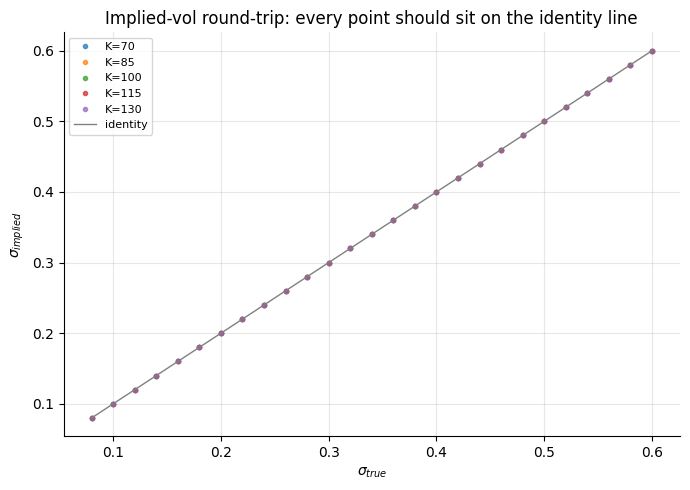

In [6]:
sig_true = np.linspace(0.08, 0.60, 27)
strikes = np.array([70.0, 85.0, 100.0, 115.0, 130.0])
Tiv = 0.5

recovered = np.empty((len(strikes), len(sig_true)))
for i, K in enumerate(strikes):
    for j, s in enumerate(sig_true):
        price = bs_price(S0, K, Tiv, r, s)
        recovered[i, j] = implied_vol(price, S0, K, Tiv, r)

max_err = np.nanmax(np.abs(recovered - sig_true[None, :]))
print(f"max |recovered - true| over {recovered.size} inversions: {max_err:.2e}")

fig, ax = plt.subplots(figsize=(7, 5))
for i, K in enumerate(strikes):
    ax.plot(sig_true, recovered[i], "o", ms=3, alpha=0.7, label=f"K={K:.0f}")
ax.plot(sig_true, sig_true, "-", color="gray", lw=1, label="identity")
ax.set_xlabel(r"$\sigma_{true}$"); ax.set_ylabel(r"$\sigma_{implied}$")
ax.set_title("Implied-vol round-trip: every point should sit on the identity line")
ax.legend(fontsize=8)
plt.tight_layout()

Every inversion lands on the identity line to about $10^{-8}$ — solver tolerance, as it should be. The practically important caveat lives *off* this happy path: for deep out-of-the-money, short-dated options, vega collapses toward zero, so a tiny price perturbation (a stale quote, half a bid-ask spread) moves implied vol violently. The inversion is mathematically well-posed but *statistically* ill-conditioned in the wings — worth remembering before trusting the edges of any empirical vol surface.

## Limitations, stated plainly

- **Agreement validates the numerics, not the model.** All four methods price the *same* GBM world. They can agree to eight digits and still all be wrong about markets — notebook 03 shows the constant-volatility assumption failing in SPY data by an order of magnitude.
- **The Monte Carlo comparison is flattered** by the exact terminal sampler; with genuinely path-dependent dynamics (Heston, CIR) discretization bias re-enters and must be budgeted separately from statistical error.
- **Errors here are for one contract family.** Barrier options, American exercise, and digital payoffs each stress different parts of a numerical method (the tree's oscillation worsens near barriers; Crank–Nicolson can ring at payoff kinks without Rannacher smoothing).
- **Greeks shown are model Greeks.** A trader hedging with Black–Scholes delta under non-BS dynamics carries a systematic hedging error that no amount of numerical precision removes.

Cross-method agreement is the beginning of trust in a pricing library, not the end of it. Models clarify uncertainty; they do not eliminate it.